In [8]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [3]:
import pandas as pd
import requests
from io import StringIO

url = "https://uniheart.pa-ca.me/proxy?url=https%3A%2F%2Fraw.githubusercontent.com%2Fhuangjia2019%2Fhouse%2Fmaster%2Fhouse.csv"
headers = {
    'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36'
}

response = requests.get(url, headers=headers)
response.raise_for_status()
df_housing = pd.read_csv(StringIO(response.content.decode('utf-8')))
df_housing.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
0,-114.31,34.19,15.0,5612.0,1283.0,1015.0,472.0,1.4936,66900.0
1,-114.47,34.40,19.0,7650.0,1901.0,1129.0,463.0,1.8200,80100.0
2,-114.56,33.69,17.0,720.0,174.0,333.0,117.0,1.6509,85700.0
3,-114.57,33.64,14.0,1501.0,337.0,515.0,226.0,3.1917,73400.0
4,-114.57,33.57,20.0,1454.0,326.0,624.0,262.0,1.9250,65500.0


In [4]:
# 构建特征集 X
X = df_housing.drop("median_house_value", axis=1)
# 构建标签集 y
y = df_housing.median_house_value

In [6]:
# 导入 sklearn 工具库
from sklearn.model_selection import train_test_split

# 以 80%/20% 的比例进行数据集的拆分
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

# 导入线性回归算法模型
from sklearn.linear_model import LinearRegression
# 确定线性回归算法
model = LinearRegression()
# 根据训练集数据，训练机器，拟合函数
model.fit(X_train, y_train)

LinearRegression()

In [7]:
# 预测验证集的 y 值
y_pred = model.predict(X_test)
print('房价的真值（测试集）', y_test)
print('预测的房价（测试集）', y_pred)

房价的真值（测试集） 3873     171400.0
3625     189600.0
3028     500001.0
13814    229400.0
15398    163400.0
           ...   
1363     212500.0
7947     210500.0
14574    142900.0
10009    128300.0
9149      84700.0
Name: median_house_value, Length: 3400, dtype: float64
预测的房价（测试集） [211157.06335416 218581.64298575 465317.31295563 ... 201751.23969632
 160873.51846957 138847.26913351]


In [8]:
# 评估预测结果
print("给预测评分：", model.score(X_test, y_test))

给预测评分： 0.6321014171579498


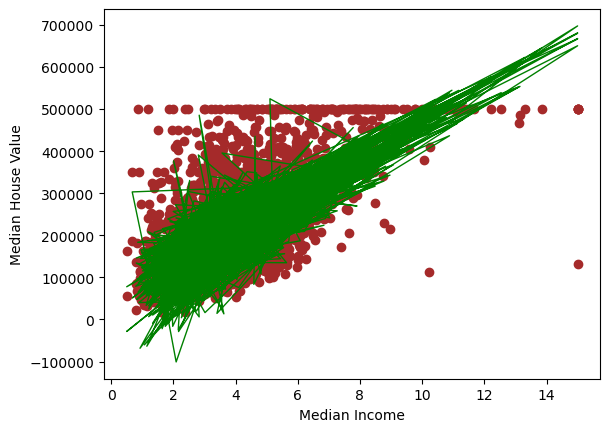

In [11]:
import matplotlib.pyplot as plt
# 用散点图显示家庭收入中位数和房价中位数的分布
plt.scatter(X_test.median_income, y_test, color='brown')
# 画出回归函数（从特征到预测标签）
plt.plot(X_test.median_income, y_pred, color='green', linewidth=1)
# x轴：家庭收入中位数
plt.xlabel('Median Income')
# y轴：房价中位数
plt.ylabel('Median House Value')
plt.show()